Este cuaderno genera imágenes sintéticas de los modelos 3D de ShapeNet. Cada archivo .ply se renderizará desde 20 posiciones de cámara fijas y reproducibles. Las imágenes resultantes se utilizarán como entrada de Pix2Vox++, mientras que los archivos model.binvox generados anteriormente constituirán el ground truth tridimensional.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip -q install blenderproc

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.5/371.5 kB 4.6 MB/s eta 0:00:00


In [3]:
!which blenderproc
!blenderproc --version

/usr/local/bin/blenderproc
2.8.0


Se define una carpeta temporal de Colab donde BlenderProc instalará Blender. Se utiliza /content porque ofrece mejor rendimiento que Google Drive. Esta instalación desaparecerá al reiniciar el entorno, pero las imágenes finales se guardarán en Drive.

In [4]:
from pathlib import Path

RUTA_BLENDER_LOCAL = Path(
    "/content/blender"
)

RUTA_PRUEBA_BLENDERPROC = Path(
    "/content/prueba_blenderproc"
)

RUTA_PRUEBA_BLENDERPROC.mkdir(
    parents=True,
    exist_ok=True
)

print("Instalación local de Blender:")
print(RUTA_BLENDER_LOCAL)

print("\nCarpeta de prueba:")
print(RUTA_PRUEBA_BLENDERPROC)

Instalación local de Blender:
/content/blender

Carpeta de prueba:
/content/prueba_blenderproc


# Probamos para una taza

In [5]:
from pathlib import Path
import random

# Datos originales
RUTA_PLY = Path(
    "/content/drive/MyDrive/Datos_E2/Shapenet_limpias"
)

# Ground truth voxel generado anteriormente
RUTA_BINVOX = Path(
    "/content/drive/MyDrive/Datos_E2/Datos_E2_voxel"
)

# Carpeta donde se guardarán las imágenes
RUTA_IMAGENES = Path(
    "/content/drive/MyDrive/Datos_E2/Img E2"
)

# Categoría de tazas
CATEGORIA_PRUEBA = "03797390"

# Selección reproducible
SEMILLA = 2026

RUTA_IMAGENES.mkdir(
    parents=True,
    exist_ok=True
)

modelos_disponibles = []

for ruta_ply in sorted(
    (RUTA_PLY / CATEGORIA_PRUEBA).glob("*.ply")
):

    identificador = ruta_ply.stem

    ruta_binvox = (
        RUTA_BINVOX
        / CATEGORIA_PRUEBA
        / identificador
        / "model.binvox"
    )

    if ruta_binvox.exists():

        modelos_disponibles.append(
            {
                "identificador": identificador,
                "ruta_ply": ruta_ply,
                "ruta_binvox": ruta_binvox
            }
        )

if len(modelos_disponibles) == 0:
    raise RuntimeError(
        "No se encontraron tazas con PLY y BINVOX."
    )

modelo_prueba = random.Random(
    SEMILLA
).choice(modelos_disponibles)

IDENTIFICADOR_PRUEBA = modelo_prueba["identificador"]
RUTA_PLY_PRUEBA = modelo_prueba["ruta_ply"]
RUTA_BINVOX_PRUEBA = modelo_prueba["ruta_binvox"]

CARPETA_MODELO_PRUEBA = (
    RUTA_IMAGENES
    / CATEGORIA_PRUEBA
    / IDENTIFICADOR_PRUEBA
)

CARPETA_RENDERING_PRUEBA = (
    CARPETA_MODELO_PRUEBA
    / "rendering"
)

CARPETA_RENDERING_PRUEBA.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_IMAGEN_00 = (
    CARPETA_RENDERING_PRUEBA
    / "00.png"
)

RUTA_CAMARA_00 = (
    CARPETA_MODELO_PRUEBA
    / "camera_pose_00.json"
)

print("Categoría:")
print(CATEGORIA_PRUEBA)

print("\nIdentificador:")
print(IDENTIFICADOR_PRUEBA)

print("\nPLY:")
print(RUTA_PLY_PRUEBA)

print("\nBINVOX:")
print(RUTA_BINVOX_PRUEBA)

print("\nImagen de salida:")
print(RUTA_IMAGEN_00)

Categoría:
03797390

Identificador:
345d3e7252156db8d44ee24d6b5498e1

PLY:
/content/drive/MyDrive/Datos_E2/Shapenet_limpias/03797390/345d3e7252156db8d44ee24d6b5498e1.ply

BINVOX:
/content/drive/MyDrive/Datos_E2/Datos_E2_voxel/03797390/345d3e7252156db8d44ee24d6b5498e1/model.binvox

Imagen de salida:
/content/drive/MyDrive/Datos_E2/Img E2/03797390/345d3e7252156db8d44ee24d6b5498e1/rendering/00.png


# Definimos la primera posicion de la cámara

La vista 00 utilizará siempre los mismos parámetros. La cámara se sitúa con azimut 0°, elevación 20° y apunta al centro del cubo normalizado.

In [6]:
AZIMUT_00 = 0.0
ELEVACION_00 = 20.0

RADIO_CAMARA = 2.2
DISTANCIA_FOCAL_MM = 50.0

ANCHO_IMAGEN = 224
ALTO_IMAGEN = 224

print("Vista: 00.png")
print("Azimut:", AZIMUT_00, "grados")
print("Elevación:", ELEVACION_00, "grados")
print("Radio:", RADIO_CAMARA)
print("Resolución:", ANCHO_IMAGEN, "x", ALTO_IMAGEN)

Vista: 00.png
Azimut: 0.0 grados
Elevación: 20.0 grados
Radio: 2.2
Resolución: 224 x 224


# Script de BlanderProc

In [7]:
from textwrap import dedent

RUTA_SCRIPT_RENDER = Path(
    "/content/render_una_vista.py"
)

codigo_blenderproc = dedent(
    r'''
    import blenderproc as bproc

    import argparse
    import json
    from pathlib import Path

    import imageio.v3 as iio
    import numpy as np


    def leer_transformacion_binvox(ruta_binvox):
        """Lee únicamente translate y scale de la cabecera BINVOX."""

        translate = None
        scale = None

        with open(ruta_binvox, "rb") as archivo:

            primera_linea = archivo.readline().strip()

            if not primera_linea.startswith(b"#binvox"):
                raise ValueError(
                    "El archivo no tiene una cabecera BINVOX válida."
                )

            while True:

                linea = archivo.readline()

                if not linea:
                    raise ValueError(
                        "No se encontró la línea 'data'."
                    )

                linea = linea.strip()

                if not linea or linea.startswith(b"#"):
                    continue

                partes = linea.split()
                campo = partes[0]

                if campo == b"translate":

                    translate = np.array(
                        [
                            float(valor)
                            for valor in partes[1:4]
                        ],
                        dtype=np.float64
                    )

                elif campo == b"scale":

                    scale = float(partes[1])

                elif campo == b"data":

                    break

        if translate is None:
            raise ValueError(
                "No se encontró translate en el BINVOX."
            )

        if scale is None or scale <= 0:
            raise ValueError(
                "La escala del BINVOX no es válida."
            )

        return translate, scale


    parser = argparse.ArgumentParser()

    parser.add_argument("--ply", required=True)
    parser.add_argument("--binvox", required=True)
    parser.add_argument("--output", required=True)
    parser.add_argument("--metadata", required=True)

    parser.add_argument("--azimuth", type=float, required=True)
    parser.add_argument("--elevation", type=float, required=True)
    parser.add_argument("--radius", type=float, required=True)

    parser.add_argument("--focal-length", type=float, required=True)
    parser.add_argument("--width", type=int, required=True)
    parser.add_argument("--height", type=int, required=True)

    args = parser.parse_args()

    ruta_salida = Path(args.output)
    ruta_metadata = Path(args.metadata)

    ruta_salida.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    ruta_metadata.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # ---------------------------------------------------------
    # Inicializar BlenderProc
    # ---------------------------------------------------------

    bproc.init()

    # ---------------------------------------------------------
    # Cargar la malla PLY
    # ---------------------------------------------------------

    objetos = bproc.loader.load_obj(
        args.ply
    )

    if len(objetos) != 1:
        raise RuntimeError(
            f"Se esperaba un objeto PLY y se cargaron {len(objetos)}."
        )

    objeto = objetos[0]

    # Suavizar la superficie únicamente para el renderizado
    # No modifica la geometría del objeto
    for cara in objeto.get_mesh().polygons:
        cara.use_smooth = True

    # ---------------------------------------------------------
    # Normalizar igual que el BINVOX
    # ---------------------------------------------------------

    translate, scale = leer_transformacion_binvox(
        args.binvox
    )

    factor_escala = 1.0 / scale

    objeto.set_scale(
        [factor_escala] * 3
    )

    objeto.set_location(
        (-translate * factor_escala).tolist()
    )

    objeto.persist_transformation_into_mesh(
        location=True,
        rotation=True,
        scale=True
    )

    # ---------------------------------------------------------
    # Material neutro y constante
    # ---------------------------------------------------------

    material = bproc.material.create(
        "material_neutro"
    )

    material.set_principled_shader_value(
        "Base Color",
        [0.65, 0.65, 0.65, 1.0]
    )

    material.set_principled_shader_value(
        "Roughness",
        0.55
    )

    objeto.replace_materials(
        material
    )

    # ---------------------------------------------------------
    # Cámara
    # ---------------------------------------------------------

    bproc.camera.set_intrinsics_from_blender_params(
        lens=args.focal_length,
        lens_unit="MILLIMETERS",
        image_width=args.width,
        image_height=args.height,
        clip_start=0.1,
        clip_end=10.0
    )

    centro = np.array(
        [0.5, 0.5, 0.5],
        dtype=np.float64
    )

    azimut_rad = np.deg2rad(
        args.azimuth
    )

    elevacion_rad = np.deg2rad(
        args.elevation
    )

    # ---------------------------------------------------------
    # Posición de cámara con +Y como eje vertical
    # ---------------------------------------------------------

    posicion_camara = centro + np.array(
        [
            args.radius
            * np.cos(elevacion_rad)
            * np.cos(azimut_rad),

            args.radius
            * np.sin(elevacion_rad),

            args.radius
            * np.cos(elevacion_rad)
            * np.sin(azimut_rad)
        ],
        dtype=np.float64
    )

    # Dirección desde la cámara hacia el centro del objeto
    forward = centro - posicion_camara
    forward = forward / np.linalg.norm(forward)

    # En ShapeNet, +Y representa la dirección vertical
    world_up = np.array(
        [0.0, 1.0, 0.0],
        dtype=np.float64
    )

    # Ejes de la cámara expresados en coordenadas del mundo
    camera_right = np.cross(
        world_up,
        forward
    )
    camera_right = (
        camera_right
        / np.linalg.norm(camera_right)
    )

    camera_up = np.cross(
        forward,
        camera_right
    )
    camera_up = (
        camera_up
        / np.linalg.norm(camera_up)
    )

    # Blender mira a través del eje local -Z de la cámara
    rotacion = np.column_stack(
        (
            camera_right,
            camera_up,
            -forward
        )
    )

    matriz_camara = (
        bproc.math.build_transformation_mat(
            posicion_camara,
            rotacion
        )
    )
    bproc.camera.add_camera_pose(
        matriz_camara
    )

    # ---------------------------------------------------------
    # Iluminación fija
    # ---------------------------------------------------------

    configuracion_luces = [
        ([2.5, -2.5, 3.5], 250),
        ([-2.0, 1.5, 2.5], 140),
        ([0.5, 2.5, 3.0], 100)
    ]

    for indice, (posicion, energia) in enumerate(
        configuracion_luces
    ):

        luz = bproc.types.Light(
            light_type="POINT",
            name=f"luz_{indice}"
        )

        luz.set_location(
            posicion
        )

        luz.set_energy(
            energia
        )

        luz.set_radius(
            0.6
        )

    # ---------------------------------------------------------
    # Renderizado
    # ---------------------------------------------------------

    bproc.renderer.set_output_format(
        file_format="PNG",
        color_depth=8,
        enable_transparency=True
    )

    bproc.renderer.set_max_amount_of_samples(
        64
    )

    bproc.renderer.set_noise_threshold(
        0.05
    )

    datos = bproc.renderer.render(
        keys_with_alpha_channel={"colors"}
    )

    imagen = datos["colors"][0]

    iio.imwrite(
        ruta_salida,
        imagen
    )

    # ---------------------------------------------------------
    # Guardar los parámetros exactos de cámara
    # ---------------------------------------------------------

    matriz_intrinseca = (
        bproc.camera.get_intrinsics_as_K_matrix()
    )

    metadata = {
        "view_id": 0,
        "filename": "00.png",
        "azimuth_deg": args.azimuth,
        "elevation_deg": args.elevation,
        "camera_radius": args.radius,

        "world_up_axis": "+Y",
        "azimuth_zero_axis": "+X",
        "azimuth_positive_direction": "+X hacia +Z",

        "focal_length_mm": args.focal_length,
        "image_width": args.width,
        "image_height": args.height,
        "target_xyz": centro.tolist(),
        "camera_location_xyz": posicion_camara.tolist(),
        "camera_to_world": matriz_camara.tolist(),
        "intrinsic_matrix_K": matriz_intrinseca.tolist(),
        "binvox_translate": translate.tolist(),
        "binvox_scale": scale
    }

    with open(
        ruta_metadata,
        "w",
        encoding="utf-8"
    ) as archivo_json:

        json.dump(
            metadata,
            archivo_json,
            indent=4
        )

    print("Imagen guardada en:")
    print(ruta_salida)

    print("Metadatos guardados en:")
    print(ruta_metadata)
    '''
)

RUTA_SCRIPT_RENDER.write_text(
    codigo_blenderproc,
    encoding="utf-8"
)

print("Script creado en:")
print(RUTA_SCRIPT_RENDER)

Script creado en:
/content/render_una_vista.py


In [8]:
import os
import subprocess

comando = [
    "blenderproc",
    "run",
    str(RUTA_SCRIPT_RENDER),

    "--blender-install-path",
    "/content/blender",

    "--ply",
    str(RUTA_PLY_PRUEBA),

    "--binvox",
    str(RUTA_BINVOX_PRUEBA),

    "--output",
    str(RUTA_IMAGEN_00),

    "--metadata",
    str(RUTA_CAMARA_00),

    "--azimuth",
    str(AZIMUT_00),

    "--elevation",
    str(ELEVACION_00),

    "--radius",
    str(RADIO_CAMARA),

    "--focal-length",
    str(DISTANCIA_FOCAL_MM),

    "--width",
    str(ANCHO_IMAGEN),

    "--height",
    str(ALTO_IMAGEN)
]

entorno = os.environ.copy()
entorno["MPLBACKEND"] = "Agg"

resultado = subprocess.run(
    comando,
    capture_output=True,
    text=True,
    env=entorno,
    timeout=600
)

print("Código de salida:")
print(resultado.returncode)

print("\nÚltimas líneas de BlenderProc:")
print(resultado.stdout[-3000:])

if resultado.returncode != 0:

    print("\nError:")
    print(resultado.stderr[-3000:])

    raise RuntimeError(
        "BlenderProc no pudo generar la imagen."
    )

if not RUTA_IMAGEN_00.exists():
    raise FileNotFoundError(
        f"No se generó la imagen:\n{RUTA_IMAGEN_00}"
    )

print("\nRender completado correctamente.")

Código de salida:
0

Últimas líneas de BlenderProc:
a (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 8.6 MB/s  0:00:00
  Created wheel for PyOpenGL: filename=pyopengl-3.1.0-py3-none-any.whl size=1745237 sha256=668940d4d8118b83168f2e70813a06ade672f5bbfa10a89d0181c9d0cd4e9e03
  Stored in directory: /root/.cache/pip/wheels/2f/37/f5/f88cd3dddf75bc3ce608e44bf8a79078c408bf1f351a50818e
Successfully built PyOpenGL

Installing pip package wheel None
Installing pip package pyyaml 6.0.1
Installing pip package imageio 2.34.1
Installing pip package gitpython 3.1.43
Installing pip package scikit-image 0.23.2
Installing pip package pypng 0.20220715.0
Installing pip package scipy 1.13.1
Installing pip package matplotlib 3.9.0
Installing pip package pytz 202

Ruta:
/content/drive/MyDrive/Datos_E2/Img E2/03797390/345d3e7252156db8d44ee24d6b5498e1/rendering/00.png

Resolución:
(224, 224)

Modo:
RGBA

Shape:
(224, 224, 4)

Porcentaje ocupado por el objeto:
31.83%

El objeto toca el borde:
False


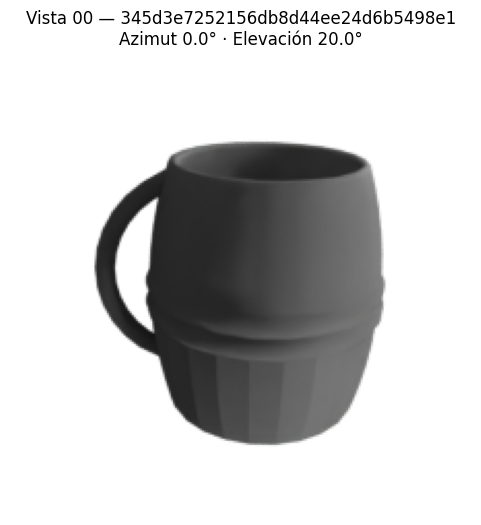

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

imagen = Image.open(
    RUTA_IMAGEN_00
)

matriz_imagen = np.array(
    imagen
)

print("Ruta:")
print(RUTA_IMAGEN_00)

print("\nResolución:")
print(imagen.size)

print("\nModo:")
print(imagen.mode)

print("\nShape:")
print(matriz_imagen.shape)

if matriz_imagen.shape[-1] != 4:
    raise ValueError(
        "La imagen no contiene cuatro canales RGBA."
    )

alpha = matriz_imagen[:, :, 3]
mascara = alpha > 0

toca_borde = bool(
    mascara[0, :].any()
    or mascara[-1, :].any()
    or mascara[:, 0].any()
    or mascara[:, -1].any()
)

print("\nPorcentaje ocupado por el objeto:")
print(f"{mascara.mean() * 100:.2f}%")

print("\nEl objeto toca el borde:")
print(toca_borde)

plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    imagen
)

plt.title(
    f"Vista 00 — {IDENTIFICADOR_PRUEBA}\n"
    f"Azimut {AZIMUT_00}° · "
    f"Elevación {ELEVACION_00}°"
)

plt.axis("off")
plt.show()

## Probamos con 5 tazas para ver si se sigue haciendo bien

In [10]:
import random
import pandas as pd

NUMERO_TAZAS_PRUEBA = 5
SEMILLA_PRUEBA_CINCO = 2026

if len(modelos_disponibles) < NUMERO_TAZAS_PRUEBA:
    raise RuntimeError(
        "No hay suficientes tazas disponibles para la prueba."
    )

modelos_prueba_cinco = random.Random(
    SEMILLA_PRUEBA_CINCO
).sample(
    modelos_disponibles,
    NUMERO_TAZAS_PRUEBA
)

df_modelos_prueba_cinco = pd.DataFrame(
    [
        {
            "categoria": CATEGORIA_PRUEBA,
            "identificador": modelo["identificador"],
            "ruta_ply": str(modelo["ruta_ply"]),
            "ruta_binvox": str(modelo["ruta_binvox"])
        }
        for modelo in modelos_prueba_cinco
    ]
)

display(df_modelos_prueba_cinco)

,categoria,identificador,ruta_ply,ruta_binvox
0,03797390,345d3e7252156db8d44ee24d6b5498e1,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...
1,03797390,7223820f07fd6b55e453535335057818,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...
2,03797390,c2e411ed6061a25ef06800d5696e457f,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...
3,03797390,c39fb75015184c2a0c7f097b1a1f7a5,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...
4,03797390,f23a544c04e2f5ccb50d0c6a0c254040,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...


In [11]:
import os
import subprocess
import numpy as np

from pathlib import Path
from PIL import Image


def renderizar_vista_00(modelo):
    """
    Renderiza la vista 00 de un modelo y valida la imagen generada.
    """

    identificador = modelo["identificador"]
    ruta_ply = Path(modelo["ruta_ply"])
    ruta_binvox = Path(modelo["ruta_binvox"])

    carpeta_modelo = (
        RUTA_IMAGENES
        / CATEGORIA_PRUEBA
        / identificador
    )

    carpeta_rendering = (
        carpeta_modelo
        / "rendering"
    )

    carpeta_rendering.mkdir(
        parents=True,
        exist_ok=True
    )

    ruta_imagen = (
        carpeta_rendering
        / "00.png"
    )

    ruta_metadata = (
        carpeta_modelo
        / "camera_pose_00.json"
    )

    comando = [
        "blenderproc",
        "run",
        str(RUTA_SCRIPT_RENDER),

        "--blender-install-path",
        "/content/blender",

        "--ply",
        str(ruta_ply),

        "--binvox",
        str(ruta_binvox),

        "--output",
        str(ruta_imagen),

        "--metadata",
        str(ruta_metadata),

        "--azimuth",
        str(AZIMUT_00),

        "--elevation",
        str(ELEVACION_00),

        "--radius",
        str(RADIO_CAMARA),

        "--focal-length",
        str(DISTANCIA_FOCAL_MM),

        "--width",
        str(ANCHO_IMAGEN),

        "--height",
        str(ALTO_IMAGEN)
    ]

    entorno = os.environ.copy()
    entorno["MPLBACKEND"] = "Agg"

    resultado = subprocess.run(
        comando,
        capture_output=True,
        text=True,
        env=entorno,
        timeout=600
    )

    if resultado.returncode != 0:

        return {
            "categoria": CATEGORIA_PRUEBA,
            "identificador": identificador,
            "ruta_imagen": str(ruta_imagen),
            "resolucion": None,
            "modo": None,
            "ocupacion_pct": None,
            "toca_borde": None,
            "valida_tecnicamente": False,
            "error": resultado.stderr[-2000:]
        }

    if not ruta_imagen.exists():

        return {
            "categoria": CATEGORIA_PRUEBA,
            "identificador": identificador,
            "ruta_imagen": str(ruta_imagen),
            "resolucion": None,
            "modo": None,
            "ocupacion_pct": None,
            "toca_borde": None,
            "valida_tecnicamente": False,
            "error": "BlenderProc no creó la imagen."
        }

    imagen = Image.open(
        ruta_imagen
    )

    matriz = np.array(
        imagen
    )

    tiene_alpha = (
        matriz.ndim == 3
        and matriz.shape[2] == 4
    )

    if tiene_alpha:

        mascara = matriz[:, :, 3] > 0

        toca_borde = bool(
            mascara[0, :].any()
            or mascara[-1, :].any()
            or mascara[:, 0].any()
            or mascara[:, -1].any()
        )

        ocupacion = float(
            mascara.mean() * 100
        )

    else:

        toca_borde = None
        ocupacion = None

    resolucion_correcta = (
        imagen.size
        == (ANCHO_IMAGEN, ALTO_IMAGEN)
    )

    valida_tecnicamente = bool(
        resolucion_correcta
        and tiene_alpha
        and mascara.any()
        and not toca_borde
    )

    return {
        "categoria": CATEGORIA_PRUEBA,
        "identificador": identificador,
        "ruta_imagen": str(ruta_imagen),
        "resolucion": str(imagen.size),
        "modo": imagen.mode,
        "ocupacion_pct": (
            round(ocupacion, 2)
            if ocupacion is not None
            else None
        ),
        "toca_borde": toca_borde,
        "valida_tecnicamente": valida_tecnicamente,
        "error": None
    }

In [12]:
from tqdm.auto import tqdm

resultados_prueba_cinco = []

for modelo in tqdm(
    modelos_prueba_cinco,
    desc="Renderizando cinco tazas"
):

    resultado_modelo = renderizar_vista_00(
        modelo
    )

    resultados_prueba_cinco.append(
        resultado_modelo
    )

df_resultados_prueba_cinco = pd.DataFrame(
    resultados_prueba_cinco
)

display(df_resultados_prueba_cinco)

Renderizando cinco tazas:   0%|          | 0/5 [00:00<?, ?it/s]

,categoria,identificador,ruta_imagen,resolucion,modo,ocupacion_pct,toca_borde,valida_tecnicamente,error
0,03797390,345d3e7252156db8d44ee24d6b5498e1,/content/drive/MyDrive/Datos_E2/Img E2/0379739...,"(224, 224)",RGBA,31.83,False,True,None
1,03797390,7223820f07fd6b55e453535335057818,/content/drive/MyDrive/Datos_E2/Img E2/0379739...,"(224, 224)",RGBA,26.15,False,True,None
2,03797390,c2e411ed6061a25ef06800d5696e457f,/content/drive/MyDrive/Datos_E2/Img E2/0379739...,"(224, 224)",RGBA,25.54,False,True,None
3,03797390,c39fb75015184c2a0c7f097b1a1f7a5,/content/drive/MyDrive/Datos_E2/Img E2/0379739...,"(224, 224)",RGBA,28.68,False,True,None
4,03797390,f23a544c04e2f5ccb50d0c6a0c254040,/content/drive/MyDrive/Datos_E2/Img E2/0379739...,"(224, 224)",RGBA,25.22,False,True,None


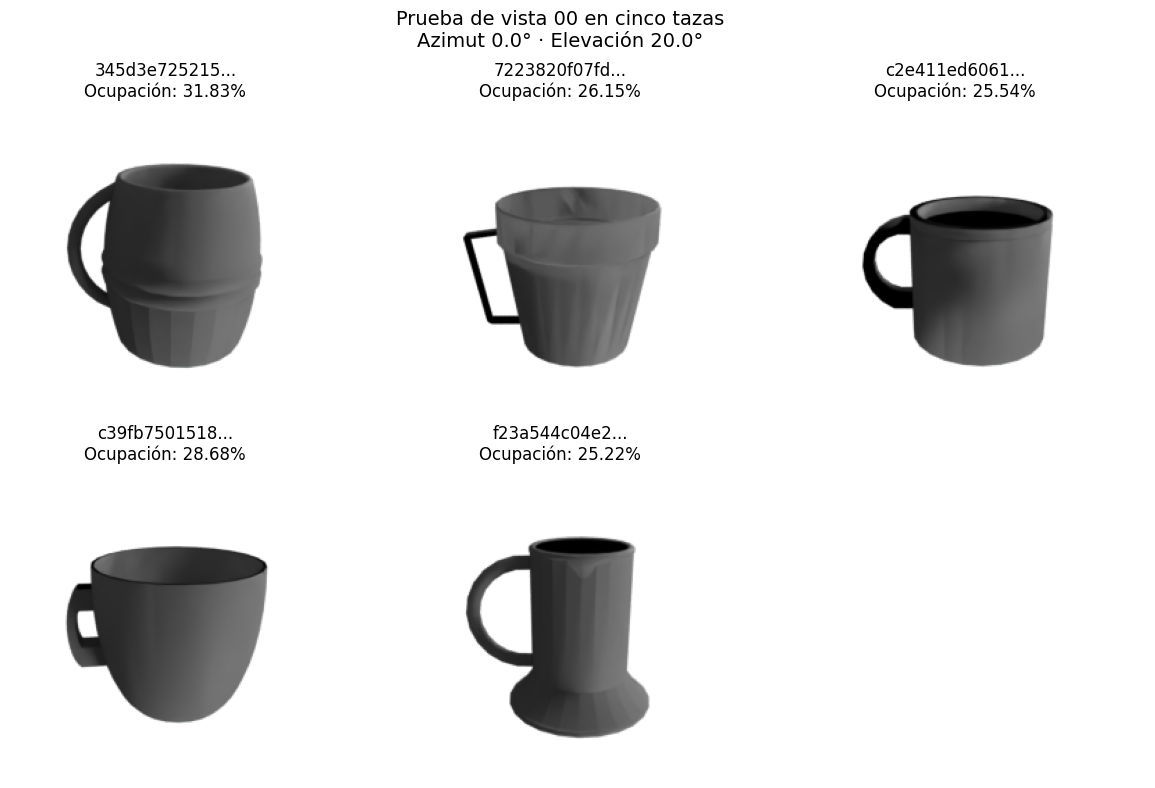

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)

axes = axes.flatten()

for indice, fila in enumerate(
    df_resultados_prueba_cinco.itertuples(index=False)
):

    imagen = Image.open(
        fila.ruta_imagen
    )

    axes[indice].imshow(
        imagen
    )

    axes[indice].set_title(
        f"{fila.identificador[:12]}...\n"
        f"Ocupación: {fila.ocupacion_pct}%"
    )

    axes[indice].axis("off")

# Ocultar el espacio sobrante
for indice in range(
    len(df_resultados_prueba_cinco),
    len(axes)
):

    axes[indice].axis("off")

plt.suptitle(
    "Prueba de vista 00 en cinco tazas\n"
    f"Azimut {AZIMUT_00}° · Elevación {ELEVACION_00}°",
    fontsize=14
)

plt.tight_layout()
plt.show()

Tiene muy buena pinta, ahora lo ejecutamos ya para todo

# Definimos las 20 vistas

In [14]:
import pandas as pd

# ---------------------------------------------------------
# Definición fija de las 20 vistas
# ---------------------------------------------------------

vistas = []

# 8 vistas a elevación 20°
for azimut in [0, 45, 90, 135, 180, 225, 270, 315]:
    vistas.append(
        {
            "view_id": len(vistas),
            "filename": f"{len(vistas):02d}.png",
            "azimuth_deg": float(azimut),
            "elevation_deg": 20.0
        }
    )

# 8 vistas a elevación 40°
for azimut in [0, 45, 90, 135, 180, 225, 270, 315]:
    vistas.append(
        {
            "view_id": len(vistas),
            "filename": f"{len(vistas):02d}.png",
            "azimuth_deg": float(azimut),
            "elevation_deg": 40.0
        }
    )

# 4 vistas a elevación 60°
for azimut in [0, 90, 180, 270]:
    vistas.append(
        {
            "view_id": len(vistas),
            "filename": f"{len(vistas):02d}.png",
            "azimuth_deg": float(azimut),
            "elevation_deg": 60.0
        }
    )

df_vistas = pd.DataFrame(vistas)

# Etiquetas útiles para experimentos
df_vistas["usar_en_1_vista"] = df_vistas["view_id"] == 0
df_vistas["usar_en_4_vistas"] = df_vistas["view_id"].isin([0, 2, 4, 6])
df_vistas["usar_en_20_vistas"] = True

display(df_vistas)

,view_id,filename,azimuth_deg,elevation_deg,usar_en_1_vista,usar_en_4_vistas,usar_en_20_vistas
0,0,00.png,0.0,20.0,True,True,True
1,1,01.png,45.0,20.0,False,False,True
2,2,02.png,90.0,20.0,False,True,True
3,3,03.png,135.0,20.0,False,False,True
4,4,04.png,180.0,20.0,False,True,True
5,5,05.png,225.0,20.0,False,False,True
6,6,06.png,270.0,20.0,False,True,True
7,7,07.png,315.0,20.0,False,False,True
8,8,08.png,0.0,40.0,False,False,True
9,9,09.png,45.0,40.0,False,False,True


## Diccionario de cámaras

In [15]:
from pathlib import Path
import json

RUTA_IMAGENES = Path("/content/drive/MyDrive/Datos_E2/Img E2")
RUTA_IMAGENES.mkdir(parents=True, exist_ok=True)

RUTA_VISTAS_CSV = RUTA_IMAGENES / "camera_views.csv"
RUTA_VISTAS_XLSX = RUTA_IMAGENES / "camera_views.xlsx"
RUTA_VISTAS_JSON = RUTA_IMAGENES / "camera_views.json"

df_vistas.to_csv(RUTA_VISTAS_CSV, index=False)
df_vistas.to_excel(RUTA_VISTAS_XLSX, index=False)

with open(RUTA_VISTAS_JSON, "w", encoding="utf-8") as f:
    json.dump(vistas, f, indent=4)

print("Archivos guardados:")
print(RUTA_VISTAS_CSV)
print(RUTA_VISTAS_XLSX)
print(RUTA_VISTAS_JSON)

Archivos guardados:
/content/drive/MyDrive/Datos_E2/Img E2/camera_views.csv
/content/drive/MyDrive/Datos_E2/Img E2/camera_views.xlsx
/content/drive/MyDrive/Datos_E2/Img E2/camera_views.json


# Script de blenderproc para las 20 vistas

In [16]:
from textwrap import dedent
from pathlib import Path

RUTA_SCRIPT_RENDER_20 = Path("/content/render_20_vistas.py")

codigo_blenderproc_20 = dedent(r'''
import blenderproc as bproc

import argparse
import json
from pathlib import Path

import imageio.v3 as iio
import numpy as np


def leer_transformacion_binvox(ruta_binvox):
    translate = None
    scale = None

    with open(ruta_binvox, "rb") as archivo:
        primera_linea = archivo.readline().strip()

        if not primera_linea.startswith(b"#binvox"):
            raise ValueError("Cabecera BINVOX no válida.")

        while True:
            linea = archivo.readline()
            if not linea:
                raise ValueError("No se encontró la línea 'data'.")

            linea = linea.strip()

            if not linea or linea.startswith(b"#"):
                continue

            partes = linea.split()
            campo = partes[0]

            if campo == b"translate":
                translate = np.array(
                    [float(v) for v in partes[1:4]],
                    dtype=np.float64
                )

            elif campo == b"scale":
                scale = float(partes[1])

            elif campo == b"data":
                break

    if translate is None:
        raise ValueError("No se encontró translate.")
    if scale is None or scale <= 0:
        raise ValueError("No se encontró una escala válida.")

    return translate, scale


parser = argparse.ArgumentParser()
parser.add_argument("--ply", required=True)
parser.add_argument("--binvox", required=True)
parser.add_argument("--views-json", required=True)
parser.add_argument("--output-dir", required=True)
parser.add_argument("--metadata-json", required=True)
parser.add_argument("--focal-length", type=float, required=True)
parser.add_argument("--width", type=int, required=True)
parser.add_argument("--height", type=int, required=True)
parser.add_argument("--radius", type=float, required=True)

args = parser.parse_args()

ruta_output_dir = Path(args.output_dir)
ruta_output_dir.mkdir(parents=True, exist_ok=True)

ruta_metadata = Path(args.metadata_json)
ruta_metadata.parent.mkdir(parents=True, exist_ok=True)

with open(args.views_json, "r", encoding="utf-8") as f:
    vistas = json.load(f)

bproc.init()

# ---------------------------------------------------------
# Cargar objeto
# ---------------------------------------------------------
objetos = bproc.loader.load_obj(args.ply)

if len(objetos) != 1:
    raise RuntimeError(
        f"Se esperaba un solo objeto y se cargaron {len(objetos)}."
    )

objeto = objetos[0]

# Suavizado visual
for cara in objeto.get_mesh().polygons:
    cara.use_smooth = True

# ---------------------------------------------------------
# Aplicar transformación consistente con BINVOX
# ---------------------------------------------------------
translate, scale = leer_transformacion_binvox(args.binvox)

factor_escala = 1.0 / scale
objeto.set_scale([factor_escala] * 3)
objeto.set_location((-translate * factor_escala).tolist())

objeto.persist_transformation_into_mesh(
    location=True,
    rotation=True,
    scale=True
)

# ---------------------------------------------------------
# Material neutro
# ---------------------------------------------------------
material = bproc.material.create("material_neutro")
material.set_principled_shader_value(
    "Base Color",
    [0.65, 0.65, 0.65, 1.0]
)
material.set_principled_shader_value("Roughness", 0.55)
objeto.replace_materials(material)

# ---------------------------------------------------------
# Cámara
# ---------------------------------------------------------
bproc.camera.set_intrinsics_from_blender_params(
    lens=args.focal_length,
    lens_unit="MILLIMETERS",
    image_width=args.width,
    image_height=args.height,
    clip_start=0.1,
    clip_end=10.0
)

centro = np.array([0.5, 0.5, 0.5], dtype=np.float64)

metadata_views = []

for vista in vistas:
    azimuth_deg = float(vista["azimuth_deg"])
    elevation_deg = float(vista["elevation_deg"])

    azimut_rad = np.deg2rad(azimuth_deg)
    elevacion_rad = np.deg2rad(elevation_deg)

    # +Y es el eje vertical del mundo
    posicion_camara = centro + np.array(
        [
            args.radius * np.cos(elevacion_rad) * np.cos(azimut_rad),
            args.radius * np.sin(elevacion_rad),
            args.radius * np.cos(elevacion_rad) * np.sin(azimut_rad)
        ],
        dtype=np.float64
    )

    forward = centro - posicion_camara
    forward = forward / np.linalg.norm(forward)

    world_up = np.array([0.0, 1.0, 0.0], dtype=np.float64)

    camera_right = np.cross(world_up, forward)
    camera_right = camera_right / np.linalg.norm(camera_right)

    camera_up = np.cross(forward, camera_right)
    camera_up = camera_up / np.linalg.norm(camera_up)

    rotacion = np.column_stack(
        (camera_right, camera_up, -forward)
    )

    matriz_camara = bproc.math.build_transformation_mat(
        posicion_camara,
        rotacion
    )

    bproc.camera.add_camera_pose(matriz_camara)

    metadata_views.append(
        {
            "view_id": int(vista["view_id"]),
            "filename": vista["filename"],
            "azimuth_deg": azimuth_deg,
            "elevation_deg": elevation_deg,
            "camera_radius": float(args.radius),
            "world_up_axis": "+Y",
            "target_xyz": centro.tolist(),
            "camera_location_xyz": posicion_camara.tolist(),
            "camera_to_world": matriz_camara.tolist()
        }
    )

# ---------------------------------------------------------
# Iluminación fija
# ---------------------------------------------------------
configuracion_luces = [
    ([2.5, -2.5, 3.5], 250),
    ([-2.0, 1.5, 2.5], 140),
    ([0.5, 2.5, 3.0], 100)
]

for i, (posicion, energia) in enumerate(configuracion_luces):
    luz = bproc.types.Light(light_type="POINT", name=f"luz_{i}")
    luz.set_location(posicion)
    luz.set_energy(energia)
    luz.set_radius(0.6)

# ---------------------------------------------------------
# Render
# ---------------------------------------------------------
bproc.renderer.set_output_format(
    file_format="PNG",
    color_depth=8,
    enable_transparency=True
)

bproc.renderer.set_max_amount_of_samples(64)
bproc.renderer.set_noise_threshold(0.05)

datos = bproc.renderer.render(
    keys_with_alpha_channel={"colors"}
)

imagenes = datos["colors"]

for vista, imagen in zip(vistas, imagenes):
    ruta_salida = ruta_output_dir / vista["filename"]
    iio.imwrite(ruta_salida, imagen)

matriz_intrinseca = bproc.camera.get_intrinsics_as_K_matrix()

metadata_global = {
    "focal_length_mm": args.focal_length,
    "image_width": args.width,
    "image_height": args.height,
    "binvox_translate": translate.tolist(),
    "binvox_scale": scale,
    "intrinsic_matrix_K": matriz_intrinseca.tolist(),
    "views": metadata_views
}

with open(ruta_metadata, "w", encoding="utf-8") as f:
    json.dump(metadata_global, f, indent=4)

print("Renderizado completado.")
print("Imágenes guardadas en:", ruta_output_dir)
print("Metadatos guardados en:", ruta_metadata)
''')

RUTA_SCRIPT_RENDER_20.write_text(
    codigo_blenderproc_20,
    encoding="utf-8"
)

print("Script creado en:")
print(RUTA_SCRIPT_RENDER_20)

Script creado en:
/content/render_20_vistas.py


In [17]:
import os
import subprocess
from pathlib import Path

RADIO_CAMARA = 2.2
DISTANCIA_FOCAL_MM = 50.0
ANCHO_IMAGEN = 224
ALTO_IMAGEN = 224

def renderizar_20_vistas_objeto(categoria, identificador, ruta_ply, ruta_binvox):
    carpeta_modelo = RUTA_IMAGENES / categoria / identificador
    carpeta_rendering = carpeta_modelo / "rendering"
    carpeta_rendering.mkdir(parents=True, exist_ok=True)

    ruta_metadata = carpeta_modelo / "camera_poses.json"

    comando = [
        "blenderproc",
        "run",
        str(RUTA_SCRIPT_RENDER_20),

        "--blender-install-path", "/content/blender",
        "--ply", str(ruta_ply),
        "--binvox", str(ruta_binvox),
        "--views-json", str(RUTA_VISTAS_JSON),
        "--output-dir", str(carpeta_rendering),
        "--metadata-json", str(ruta_metadata),
        "--focal-length", str(DISTANCIA_FOCAL_MM),
        "--width", str(ANCHO_IMAGEN),
        "--height", str(ALTO_IMAGEN),
        "--radius", str(RADIO_CAMARA)
    ]

    entorno = os.environ.copy()
    entorno["MPLBACKEND"] = "Agg"

    resultado = subprocess.run(
        comando,
        capture_output=True,
        text=True,
        env=entorno,
        timeout=1200
    )

    if resultado.returncode != 0:
        return {
            "categoria": categoria,
            "identificador": identificador,
            "estado": "error",
            "n_imagenes": None,
            "error": resultado.stderr[-2000:]
        }

    imagenes = sorted(carpeta_rendering.glob("*.png"))

    return {
        "categoria": categoria,
        "identificador": identificador,
        "estado": "ok",
        "n_imagenes": len(imagenes),
        "error": None
    }

## Probamos 20 vistas de una taza

In [18]:
# resultado_20_prueba = renderizar_20_vistas_objeto(
#     categoria=CATEGORIA_PRUEBA,
#     identificador=IDENTIFICADOR_PRUEBA,
#     ruta_ply=RUTA_PLY_PRUEBA,
#     ruta_binvox=RUTA_BINVOX_PRUEBA
# )

# resultado_20_prueba

In [19]:
# from PIL import Image
# import matplotlib.pyplot as plt

# def mostrar_20_vistas(categoria, identificador):
#     carpeta_rendering = (
#         RUTA_IMAGENES / categoria / identificador / "rendering"
#     )

#     rutas = sorted(carpeta_rendering.glob("*.png"))

#     if len(rutas) == 0:
#         raise RuntimeError("No se encontraron imágenes.")

#     fig, axes = plt.subplots(4, 5, figsize=(15, 12))
#     axes = axes.flatten()

#     for i, ruta in enumerate(rutas):
#         imagen = Image.open(ruta)
#         axes[i].imshow(imagen)
#         axes[i].set_title(ruta.name)
#         axes[i].axis("off")

#     for i in range(len(rutas), len(axes)):
#         axes[i].axis("off")

#     plt.suptitle(f"{categoria} / {identificador}", fontsize=14)
#     plt.tight_layout()
#     plt.show()

# mostrar_20_vistas(CATEGORIA_PRUEBA, IDENTIFICADOR_PRUEBA)

In [20]:
# from pathlib import Path
# import pandas as pd

# RUTA_PLY = Path(
#     "/content/drive/MyDrive/Datos_E2/Shapenet_limpias"
# )

# RUTA_BINVOX = Path(
#     "/content/drive/MyDrive/Datos_E2/Datos_E2_voxel"
# )

# RUTA_INFORME_BINVOX = (
#     RUTA_BINVOX
#     / "binvox_validation_report.csv"
# )

# if not RUTA_INFORME_BINVOX.exists():
#     raise FileNotFoundError(
#         f"No existe el informe:\n{RUTA_INFORME_BINVOX}"
#     )

# # Leer categorías e identificadores como texto
# # para conservar los ceros iniciales
# df_validacion_previa = pd.read_csv(
#     RUTA_INFORME_BINVOX,
#     dtype={
#         "categoria": str,
#         "identificador": str
#     }
# )

# df_validacion_previa["categoria"] = (
#     df_validacion_previa["categoria"]
#     .str.zfill(8)
# )

# # Comprobar que el informe anterior no contiene inválidos
# if "valido" in df_validacion_previa.columns:

#     columna_valido = (
#         df_validacion_previa["valido"]
#         .astype(str)
#         .str.lower()
#         .eq("true")
#     )

#     if not columna_valido.all():
#         raise RuntimeError(
#             "El informe contiene BINVOX inválidos."
#         )

# # Construir directamente las rutas.
# # No se consulta Google Drive archivo por archivo.
# df_render = df_validacion_previa[
#     ["categoria", "identificador"]
# ].copy()

# df_render["ruta_ply"] = df_render.apply(
#     lambda fila: str(
#         RUTA_PLY
#         / fila["categoria"]
#         / f"{fila['identificador']}.ply"
#     ),
#     axis=1
# )

# df_render["ruta_binvox"] = df_render.apply(
#     lambda fila: str(
#         RUTA_BINVOX
#         / fila["categoria"]
#         / fila["identificador"]
#         / "model.binvox"
#     ),
#     axis=1
# )

# df_render = (
#     df_render
#     .sort_values(["categoria", "identificador"])
#     .reset_index(drop=True)
# )

# print("Objetos listos para renderizar:", len(df_render))
# print("Categorías:", df_render["categoria"].nunique())

# display(df_render.head())

# Probamos un objeto de cada categoria

Se selecciona de forma reproducible un modelo de cada categoría y se generan sus veinte vistas antes de ejecutar el dataset completo.

In [21]:
# import pandas as pd
# from tqdm.auto import tqdm

# # Seleccionar un modelo por categoría
# muestra_todas_categorias = (
#     df_render
#     .sort_values(["categoria", "identificador"])
#     .groupby("categoria", group_keys=False)
#     .sample(n=1, random_state=2026)
#     .reset_index(drop=True)
# )

# print("Categorías que se probarán:")
# display(
#     muestra_todas_categorias[
#         ["categoria", "identificador"]
#     ]
# )

# resultados_prueba_categorias = []

# for fila in tqdm(
#     muestra_todas_categorias.itertuples(index=False),
#     total=len(muestra_todas_categorias),
#     desc="Probando categorías"
# ):

#     resultado = renderizar_20_vistas_objeto(
#         categoria=fila.categoria,
#         identificador=fila.identificador,
#         ruta_ply=Path(fila.ruta_ply),
#         ruta_binvox=Path(fila.ruta_binvox)
#     )

#     resultados_prueba_categorias.append(resultado)

# df_prueba_categorias = pd.DataFrame(
#     resultados_prueba_categorias
# )

# display(df_prueba_categorias)

In [22]:
# prueba_correcta = bool(
#     (df_prueba_categorias["estado"] == "ok").all()
#     and (df_prueba_categorias["n_imagenes"] == 20).all()
#     and df_prueba_categorias["error"].isna().all()
# )

# print("Prueba correcta:", prueba_correcta)

# if not prueba_correcta:
#     display(
#         df_prueba_categorias[
#             (df_prueba_categorias["estado"] != "ok")
#             | (df_prueba_categorias["n_imagenes"] != 20)
#             | df_prueba_categorias["error"].notna()
#         ]
#     )

In [23]:
# for fila in muestra_todas_categorias.itertuples(index=False):

#     mostrar_20_vistas(
#         categoria=fila.categoria,
#         identificador=fila.identificador
#     )

# Rollout Completo

In [24]:
from pathlib import Path
import pandas as pd

# ---------------------------------------------------------
# Rutas generales
# ---------------------------------------------------------

RUTA_PLY = Path(
    "/content/drive/MyDrive/Datos_E2/Shapenet_limpias"
)

RUTA_BINVOX = Path(
    "/content/drive/MyDrive/Datos_E2/Datos_E2_voxel"
)

RUTA_IMAGENES = Path(
    "/content/drive/MyDrive/Datos_E2/Img E2"
)

RUTA_INFORME_BINVOX = (
    RUTA_BINVOX
    / "binvox_validation_report.csv"
)

CATEGORIA_TAZAS = "03797390"

RUTA_IMAGENES.mkdir(
    parents=True,
    exist_ok=True
)

# ---------------------------------------------------------
# Leer el informe de BINVOX ya validado
# ---------------------------------------------------------

if not RUTA_INFORME_BINVOX.exists():
    raise FileNotFoundError(
        f"No existe el informe BINVOX:\n"
        f"{RUTA_INFORME_BINVOX}"
    )

df_validacion_previa = pd.read_csv(
    RUTA_INFORME_BINVOX,
    dtype={
        "categoria": str,
        "identificador": str
    }
)

df_validacion_previa["categoria"] = (
    df_validacion_previa["categoria"]
    .str.zfill(8)
)

# Utilizar únicamente BINVOX válidos
if "valido" in df_validacion_previa.columns:

    mascara_valida = (
        df_validacion_previa["valido"]
        .astype(str)
        .str.lower()
        .eq("true")
    )

    df_validacion_previa = (
        df_validacion_previa.loc[
            mascara_valida
        ]
        .copy()
    )

# ---------------------------------------------------------
# Crear df_render
# ---------------------------------------------------------

df_render = df_validacion_previa[
    [
        "categoria",
        "identificador"
    ]
].copy()

df_render["ruta_ply"] = (
    df_render["categoria"].map(str)
    .radd(str(RUTA_PLY) + "/")
    + "/"
    + df_render["identificador"].map(str)
    + ".ply"
)

df_render["ruta_binvox"] = (
    df_render["categoria"].map(str)
    .radd(str(RUTA_BINVOX) + "/")
    + "/"
    + df_render["identificador"].map(str)
    + "/model.binvox"
)

df_render = (
    df_render
    .drop_duplicates(
        subset=[
            "categoria",
            "identificador"
        ]
    )
    .sort_values(
        [
            "categoria",
            "identificador"
        ]
    )
    .reset_index(drop=True)
)

print("Objetos disponibles:", len(df_render))
print("Categorías disponibles:", df_render["categoria"].nunique())

print("\nObjetos por categoría:")
display(
    df_render["categoria"]
    .value_counts()
    .sort_index()
    .rename("numero_objetos")
    .to_frame()
)

display(df_render.head())

Objetos disponibles: 2170
Categorías disponibles: 7

Objetos por categoría:


,numero_objetos
categoria,
02747177,277
02876657,453
02880940,146
02946921,88
03593526,545
03797390,172
03991062,489


,categoria,identificador,ruta_ply,ruta_binvox
0,02747177,10839d0dc35c94fcf4fb4dee5181bee,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...
1,02747177,11d2b7d8c377632bd4d8765e3910f617,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...
2,02747177,126ae26edcd76f27ad5067eac75a07f7,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...
3,02747177,12c4048e0d2f26a763b2acb037dfbcde,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...
4,02747177,1532546ac3d8a2cff155d75bbf62b80,/content/drive/MyDrive/Datos_E2/Shapenet_limpi...,/content/drive/MyDrive/Datos_E2/Datos_E2_voxel...


In [25]:
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd

SOBRESCRIBIR_IMAGENES = False

def renderizar_categoria(categoria, sobrescribir=False, guardar_csv=True):
    """
    Renderiza todos los objetos de una categoría concreta.

    Parámetros:
    - categoria: código ShapeNet, por ejemplo "03797390"
    - sobrescribir: si True, vuelve a renderizar aunque ya existan 20 imágenes
    - guardar_csv: si True, guarda un informe CSV de la categoría

    Devuelve:
    - DataFrame con los resultados de la categoría
    """

    categoria = str(categoria).zfill(8)

    df_categoria = (
        df_render[
            df_render["categoria"] == categoria
        ]
        .copy()
        .reset_index(drop=True)
    )

    if df_categoria.empty:
        raise RuntimeError(
            f"No se encontraron objetos para la categoría {categoria}"
        )

    print(f"Categoría: {categoria}")
    print(f"Objetos a revisar: {len(df_categoria)}")

    resultados_render = []

    for fila in tqdm(
        df_categoria.itertuples(index=False),
        total=len(df_categoria),
        desc=f"Renderizando categoría {categoria}"
    ):
        carpeta_rendering = (
            RUTA_IMAGENES / fila.categoria / fila.identificador / "rendering"
        )

        imagenes_existentes = sorted(carpeta_rendering.glob("*.png"))

        if len(imagenes_existentes) == 20 and not sobrescribir:
            resultados_render.append(
                {
                    "categoria": fila.categoria,
                    "identificador": fila.identificador,
                    "estado": "existente_valido",
                    "n_imagenes": 20,
                    "error": None
                }
            )
            continue

        resultado = renderizar_20_vistas_objeto(
            categoria=fila.categoria,
            identificador=fila.identificador,
            ruta_ply=Path(fila.ruta_ply),
            ruta_binvox=Path(fila.ruta_binvox)
        )

        resultados_render.append(resultado)

    df_resultados_categoria = pd.DataFrame(resultados_render)

    if guardar_csv:
        ruta_csv = (
            RUTA_IMAGENES
            / f"rendering_report_{categoria}.csv"
        )

        df_resultados_categoria.to_csv(
            ruta_csv,
            index=False
        )

        print("\nInforme guardado en:")
        print(ruta_csv)

    print("\nResumen:")
    print(df_resultados_categoria["estado"].value_counts())

    return df_resultados_categoria

In [26]:
def validar_categoria_renderizada(categoria):
    categoria = str(categoria).zfill(8)

    df_categoria = (
        df_render[
            df_render["categoria"] == categoria
        ]
        .copy()
        .reset_index(drop=True)
    )

    validacion = []

    for fila in df_categoria.itertuples(index=False):
        carpeta_rendering = (
            RUTA_IMAGENES / fila.categoria / fila.identificador / "rendering"
        )

        imagenes = sorted(carpeta_rendering.glob("*.png"))

        metadata_json = (
            RUTA_IMAGENES / fila.categoria / fila.identificador / "camera_poses.json"
        )

        validacion.append(
            {
                "categoria": fila.categoria,
                "identificador": fila.identificador,
                "n_imagenes": len(imagenes),
                "metadata_ok": metadata_json.exists(),
                "valido": len(imagenes) == 20 and metadata_json.exists()
            }
        )

    df_validacion = pd.DataFrame(validacion)

    ruta_csv = (
        RUTA_IMAGENES
        / f"render_validation_report_{categoria}.csv"
    )

    df_validacion.to_csv(ruta_csv, index=False)

    print("Informe de validación guardado en:")
    print(ruta_csv)

    print("\nResumen:")
    print("Objetos válidos:", int(df_validacion["valido"].sum()))
    print("Objetos inválidos:", int((~df_validacion["valido"]).sum()))

    return df_validacion

# Ejecuto un renderizado para cada una de las otras categorias

In [27]:
# Tazas
# Hecho df_resultados_03797390 = renderizar_categoria("03797390")



In [28]:
# Validación de tazas
# Hecho df_validacion_03797390 = validar_categoria_renderizada("03797390")

# Una vez esto esté hecho

In [29]:
from pathlib import Path
import pandas as pd

CATEGORIA_TAZAS = "03797390"

RUTA_REPORTE_TAZAS = (
    RUTA_IMAGENES
    / f"rendering_report_{CATEGORIA_TAZAS}.csv"
)

if not RUTA_REPORTE_TAZAS.exists():
    raise FileNotFoundError(
        "Todavía no existe el informe de tazas:\n"
        f"{RUTA_REPORTE_TAZAS}\n\n"
        "La categoría debe terminar de renderizarse primero."
    )

df_resultados_tazas = pd.read_csv(
    RUTA_REPORTE_TAZAS,
    dtype={
        "categoria": str,
        "identificador": str
    }
)

df_resultados_tazas["categoria"] = (
    df_resultados_tazas["categoria"].str.zfill(8)
)

df_resultados_tazas["n_imagenes"] = pd.to_numeric(
    df_resultados_tazas["n_imagenes"],
    errors="coerce"
)

estados_correctos = {
    "ok",
    "existente_valido"
}

df_resultados_tazas["render_correcto"] = (
    df_resultados_tazas["estado"].isin(estados_correctos)
    & df_resultados_tazas["n_imagenes"].eq(20)
    & df_resultados_tazas["error"].isna()
)

print("RESUMEN DEL RENDERIZADO DE TAZAS\n")

print("Tazas incluidas:", len(df_resultados_tazas))
print(
    "Renderizadas correctamente:",
    int(df_resultados_tazas["render_correcto"].sum())
)
print(
    "Con problemas:",
    int((~df_resultados_tazas["render_correcto"]).sum())
)

print("\nEstados:")
print(df_resultados_tazas["estado"].value_counts())

if not df_resultados_tazas["render_correcto"].all():

    print("\nTazas con problemas:")

    display(
        df_resultados_tazas.loc[
            ~df_resultados_tazas["render_correcto"],
            [
                "categoria",
                "identificador",
                "estado",
                "n_imagenes",
                "error"
            ]
        ]
    )

RESUMEN DEL RENDERIZADO DE TAZAS

Tazas incluidas: 172
Renderizadas correctamente: 172
Con problemas: 0

Estados:
estado
ok                  170
existente_valido      2
Name: count, dtype: int64


In [30]:
def validar_estructura_categoria(categoria):
    """
    Comprueba que cada objeto tenga:
    - exactamente 20 PNG;
    - nombres desde 00.png hasta 19.png;
    - camera_poses.json.
    """

    categoria = str(categoria).zfill(8)

    df_categoria = (
        df_render.loc[
            df_render["categoria"] == categoria
        ]
        .copy()
        .reset_index(drop=True)
    )

    if df_categoria.empty:
        raise RuntimeError(
            f"No hay modelos de la categoría {categoria}."
        )

    nombres_esperados = {
        f"{indice:02d}.png"
        for indice in range(20)
    }

    resultados = []

    for fila in df_categoria.itertuples(index=False):

        carpeta_modelo = (
            RUTA_IMAGENES
            / categoria
            / fila.identificador
        )

        carpeta_rendering = (
            carpeta_modelo
            / "rendering"
        )

        rutas_png = sorted(
            carpeta_rendering.glob("*.png")
        )

        nombres_encontrados = {
            ruta.name
            for ruta in rutas_png
        }

        nombres_faltantes = sorted(
            nombres_esperados
            - nombres_encontrados
        )

        nombres_adicionales = sorted(
            nombres_encontrados
            - nombres_esperados
        )

        ruta_metadata = (
            carpeta_modelo
            / "camera_poses.json"
        )

        valido = bool(
            len(rutas_png) == 20
            and not nombres_faltantes
            and not nombres_adicionales
            and ruta_metadata.exists()
        )

        resultados.append(
            {
                "categoria": categoria,
                "identificador": fila.identificador,
                "n_imagenes": len(rutas_png),
                "imagenes_faltantes": ";".join(
                    nombres_faltantes
                ),
                "imagenes_adicionales": ";".join(
                    nombres_adicionales
                ),
                "metadata_ok": ruta_metadata.exists(),
                "valido": valido
            }
        )

    df_validacion = pd.DataFrame(resultados)

    ruta_informe = (
        RUTA_IMAGENES
        / f"render_validation_report_{categoria}.csv"
    )

    df_validacion.to_csv(
        ruta_informe,
        index=False
    )

    print("Categoría:", categoria)
    print("Objetos revisados:", len(df_validacion))
    print(
        "Objetos válidos:",
        int(df_validacion["valido"].sum())
    )
    print(
        "Objetos inválidos:",
        int((~df_validacion["valido"]).sum())
    )

    print("\nInforme guardado en:")
    print(ruta_informe)

    return df_validacion

In [31]:
# df_validacion_tazas = validar_estructura_categoria("03797390")

# Visualizamos un objeto aleatorio

In [32]:
import numpy as np

from PIL import Image
from tqdm.auto import tqdm


def validar_imagenes_categoria(categoria):
    """
    Valida el contenido técnico de las 20 imágenes
    de todos los objetos de una categoría.
    """

    categoria = str(categoria).zfill(8)

    df_categoria = (
        df_render.loc[
            df_render["categoria"] == categoria
        ]
        .copy()
        .reset_index(drop=True)
    )

    resultados = []

    total_imagenes = len(df_categoria) * 20

    with tqdm(
        total=total_imagenes,
        desc=f"Validando imágenes {categoria}"
    ) as barra:

        for fila in df_categoria.itertuples(index=False):

            carpeta_rendering = (
                RUTA_IMAGENES
                / categoria
                / fila.identificador
                / "rendering"
            )

            for view_id in range(20):

                nombre_imagen = f"{view_id:02d}.png"

                ruta_imagen = (
                    carpeta_rendering
                    / nombre_imagen
                )

                registro = {
                    "categoria": categoria,
                    "identificador": fila.identificador,
                    "view_id": view_id,
                    "filename": nombre_imagen,
                    "ruta_imagen": str(ruta_imagen),
                    "resolucion": None,
                    "modo": None,
                    "ocupacion_pct": None,
                    "toca_borde": None,
                    "valida": False,
                    "error": None
                }

                try:

                    if not ruta_imagen.exists():
                        raise FileNotFoundError(
                            "La imagen no existe."
                        )

                    with Image.open(ruta_imagen) as imagen:

                        matriz = np.asarray(imagen)

                        registro["resolucion"] = str(
                            imagen.size
                        )

                        registro["modo"] = imagen.mode

                    resolucion_correcta = (
                        matriz.shape[:2]
                        == (224, 224)
                    )

                    tiene_alpha = bool(
                        matriz.ndim == 3
                        and matriz.shape[2] == 4
                    )

                    if not tiene_alpha:
                        raise ValueError(
                            "La imagen no tiene cuatro canales RGBA."
                        )

                    mascara = matriz[:, :, 3] > 0

                    objeto_visible = bool(
                        mascara.any()
                    )

                    toca_borde = bool(
                        mascara[0, :].any()
                        or mascara[-1, :].any()
                        or mascara[:, 0].any()
                        or mascara[:, -1].any()
                    )

                    registro["ocupacion_pct"] = round(
                        float(mascara.mean() * 100),
                        2
                    )

                    registro["toca_borde"] = toca_borde

                    registro["valida"] = bool(
                        resolucion_correcta
                        and tiene_alpha
                        and objeto_visible
                        and not toca_borde
                    )

                except Exception as error:

                    registro["error"] = (
                        f"{type(error).__name__}: {error}"
                    )

                resultados.append(registro)
                barra.update(1)

    df_validacion_imagenes = pd.DataFrame(
        resultados
    )

    ruta_informe = (
        RUTA_IMAGENES
        / f"image_validation_report_{categoria}.csv"
    )

    df_validacion_imagenes.to_csv(
        ruta_informe,
        index=False
    )

    print("\nImágenes revisadas:", len(df_validacion_imagenes))
    print(
        "Imágenes válidas:",
        int(df_validacion_imagenes["valida"].sum())
    )
    print(
        "Imágenes inválidas:",
        int((~df_validacion_imagenes["valida"]).sum())
    )

    print("\nInforme guardado en:")
    print(ruta_informe)

    return df_validacion_imagenes

In [33]:
# df_validacion_imagenes_tazas = validar_imagenes_categoria("03797390")

# Resumen tecnico

In [34]:
# print("RESUMEN TÉCNICO DE LAS TAZAS\n")

# print(
#     "Número de imágenes:",
#     len(df_validacion_imagenes_tazas)
# )

# print(
#     "Imágenes válidas:",
#     int(df_validacion_imagenes_tazas["valida"].sum())
# )

# print(
#     "Imágenes inválidas:",
#     int((~df_validacion_imagenes_tazas["valida"]).sum())
# )

# print("\nOcupación visual:")

# display(
#     df_validacion_imagenes_tazas[
#         "ocupacion_pct"
#     ].describe()
# )

# imagenes_invalidas = (
#     df_validacion_imagenes_tazas.loc[
#         ~df_validacion_imagenes_tazas["valida"]
#     ]
# )

# if imagenes_invalidas.empty:

#     print(
#         "\nCorrecto: todas las imágenes de las tazas "
#         "han superado la validación."
#     )

# else:

#     print("\nImágenes con problemas:")

#     display(
#         imagenes_invalidas[
#             [
#                 "identificador",
#                 "view_id",
#                 "filename",
#                 "resolucion",
#                 "modo",
#                 "toca_borde",
#                 "error"
#             ]
#         ]
#     )

In [35]:
# import random
# import matplotlib.pyplot as plt


# def mostrar_taza_aleatoria(
#     view_id=None,
#     semilla=None
# ):
#     """
#     Muestra una vista de una taza aleatoria.

#     view_id:
#     - None: elige una vista aleatoria.
#     - 0 a 19: muestra esa vista concreta.
#     """

#     if "df_validacion_tazas" in globals():

#         candidatos = df_validacion_tazas.loc[
#             df_validacion_tazas["valido"]
#         ].copy()

#     else:

#         candidatos = df_render.loc[
#             df_render["categoria"] == CATEGORIA_TAZAS
#         ].copy()

#     if candidatos.empty:
#         raise RuntimeError(
#             "No hay tazas válidas para visualizar."
#         )

#     generador = random.Random(semilla)

#     fila = candidatos.iloc[
#         generador.randrange(len(candidatos))
#     ]

#     if view_id is None:
#         view_id = generador.randrange(20)

#     if view_id not in range(20):
#         raise ValueError(
#             "view_id debe estar entre 0 y 19."
#         )

#     identificador = fila["identificador"]

#     ruta_imagen = (
#         RUTA_IMAGENES
#         / CATEGORIA_TAZAS
#         / identificador
#         / "rendering"
#         / f"{view_id:02d}.png"
#     )

#     imagen = Image.open(
#         ruta_imagen
#     )

#     datos_vista = df_vistas.loc[
#         df_vistas["view_id"] == view_id
#     ].iloc[0]

#     plt.figure(figsize=(6, 6))

#     plt.imshow(imagen)

#     plt.title(
#         f"Taza {identificador}\n"
#         f"Vista {view_id:02d} · "
#         f"Azimut {datos_vista['azimuth_deg']}° · "
#         f"Elevación {datos_vista['elevation_deg']}°"
#     )

#     plt.axis("off")
#     plt.show()

#     return {
#         "categoria": CATEGORIA_TAZAS,
#         "identificador": identificador,
#         "view_id": view_id,
#         "ruta_imagen": ruta_imagen
#     }

In [36]:
# # Taza y vista aleatorias
# mostrar_taza_aleatoria()

## 20 vistas

In [37]:
# def mostrar_20_vistas_taza_aleatoria(
#     semilla=None
# ):
#     generador = random.Random(semilla)

#     if "df_validacion_tazas" in globals():

#         candidatos = df_validacion_tazas.loc[
#             df_validacion_tazas["valido"]
#         ].copy()

#     else:

#         candidatos = df_render.loc[
#             df_render["categoria"] == CATEGORIA_TAZAS
#         ].copy()

#     if candidatos.empty:
#         raise RuntimeError(
#             "No hay tazas disponibles."
#         )

#     fila = candidatos.iloc[
#         generador.randrange(len(candidatos))
#     ]

#     identificador = fila["identificador"]

#     mostrar_20_vistas(
#         categoria=CATEGORIA_TAZAS,
#         identificador=identificador
#     )

#     return {
#         "categoria": CATEGORIA_TAZAS,
#         "identificador": identificador
#     }

In [38]:
# mostrar_20_vistas_taza_aleatoria()

# Actualizar un informe global

In [39]:
import re


def cargar_informes_categorias(prefijo):
    """
    Carga únicamente informes cuyo nombre termina
    en un código ShapeNet de ocho dígitos.
    """

    dataframes = []

    for ruta_csv in sorted(
        RUTA_IMAGENES.glob(
            f"{prefijo}_*.csv"
        )
    ):

        patron = (
            rf"{re.escape(prefijo)}_"
            rf"(\d{{8}})"
        )

        coincidencia = re.fullmatch(
            patron,
            ruta_csv.stem
        )

        if coincidencia is None:
            continue

        categoria = coincidencia.group(1)

        df_informe = pd.read_csv(
            ruta_csv,
            dtype={
                "categoria": str,
                "identificador": str
            }
        )

        df_informe["categoria"] = (
            df_informe["categoria"]
            .str.zfill(8)
        )

        df_informe["informe_origen"] = (
            ruta_csv.name
        )

        df_informe["categoria_informe"] = categoria

        dataframes.append(
            df_informe
        )

    if not dataframes:
        return pd.DataFrame()

    return pd.concat(
        dataframes,
        ignore_index=True
    )


def actualizar_informes_globales():
    """
    Combina los informes individuales de todas las
    categorías que ya hayan terminado.
    """

    # -----------------------------------------------------
    # Informe global de renderizado
    # -----------------------------------------------------

    df_render_global = cargar_informes_categorias(
        "rendering_report"
    )

    if not df_render_global.empty:

        df_render_global = (
            df_render_global
            .drop_duplicates(
                subset=[
                    "categoria",
                    "identificador"
                ],
                keep="last"
            )
            .sort_values(
                [
                    "categoria",
                    "identificador"
                ]
            )
            .reset_index(drop=True)
        )

        ruta_render_global = (
            RUTA_IMAGENES
            / "rendering_report_global.csv"
        )

        df_render_global.to_csv(
            ruta_render_global,
            index=False
        )

    else:

        ruta_render_global = None

    # -----------------------------------------------------
    # Informe global de validación estructural
    # -----------------------------------------------------

    df_validacion_global = (
        cargar_informes_categorias(
            "render_validation_report"
        )
    )

    if not df_validacion_global.empty:

        df_validacion_global = (
            df_validacion_global
            .drop_duplicates(
                subset=[
                    "categoria",
                    "identificador"
                ],
                keep="last"
            )
            .sort_values(
                [
                    "categoria",
                    "identificador"
                ]
            )
            .reset_index(drop=True)
        )

        ruta_validacion_global = (
            RUTA_IMAGENES
            / "render_validation_report_global.csv"
        )

        df_validacion_global.to_csv(
            ruta_validacion_global,
            index=False
        )

    else:

        ruta_validacion_global = None

    # -----------------------------------------------------
    # Resumen de progreso por categoría
    # -----------------------------------------------------

    df_progreso = (
        df_render
        .groupby("categoria")
        .size()
        .rename("objetos_esperados")
        .reset_index()
    )

    if not df_render_global.empty:

        progreso_render = (
            df_render_global
            .groupby("categoria")
            .agg(
                objetos_informados=(
                    "identificador",
                    "nunique"
                ),
                objetos_ok=(
                    "estado",
                    lambda serie: int(
                        serie.isin(
                            [
                                "ok",
                                "existente_valido"
                            ]
                        ).sum()
                    )
                )
            )
            .reset_index()
        )

        df_progreso = df_progreso.merge(
            progreso_render,
            on="categoria",
            how="left"
        )

    else:

        df_progreso["objetos_informados"] = 0
        df_progreso["objetos_ok"] = 0

    if not df_validacion_global.empty:

        df_validacion_global["valido"] = (
            df_validacion_global["valido"]
            .astype(str)
            .str.lower()
            .eq("true")
        )

        progreso_validacion = (
            df_validacion_global
            .groupby("categoria")
            .agg(
                objetos_validados=(
                    "identificador",
                    "nunique"
                ),
                objetos_validos=(
                    "valido",
                    "sum"
                )
            )
            .reset_index()
        )

        df_progreso = df_progreso.merge(
            progreso_validacion,
            on="categoria",
            how="left"
        )

    else:

        df_progreso["objetos_validados"] = 0
        df_progreso["objetos_validos"] = 0

    columnas_numericas = [
        "objetos_informados",
        "objetos_ok",
        "objetos_validados",
        "objetos_validos"
    ]

    for columna in columnas_numericas:

        if columna not in df_progreso.columns:
            df_progreso[columna] = 0

        df_progreso[columna] = (
            df_progreso[columna]
            .fillna(0)
            .astype(int)
        )

    df_progreso["render_completo"] = (
        df_progreso["objetos_ok"]
        == df_progreso["objetos_esperados"]
    )

    df_progreso["validacion_completa"] = (
        df_progreso["objetos_validos"]
        == df_progreso["objetos_esperados"]
    )

    ruta_progreso = (
        RUTA_IMAGENES
        / "rendering_progress_by_category.csv"
    )

    df_progreso.to_csv(
        ruta_progreso,
        index=False
    )

    print("INFORMES GLOBALES ACTUALIZADOS\n")

    if ruta_render_global is not None:
        print("Renderizado:")
        print(ruta_render_global)

    if ruta_validacion_global is not None:
        print("\nValidación:")
        print(ruta_validacion_global)

    print("\nProgreso:")
    print(ruta_progreso)

    display(df_progreso)

    return {
        "renderizado": df_render_global,
        "validacion": df_validacion_global,
        "progreso": df_progreso
    }

# Falta por hacer

In [40]:
# Otras
df_resultados_03991062 = renderizar_categoria("03991062")

Categoría: 03991062
Objetos a revisar: 489


Renderizando categoría 03991062:   0%|          | 0/489 [00:00<?, ?it/s]


Informe guardado en:
/content/drive/MyDrive/Datos_E2/Img E2/rendering_report_03991062.csv

Resumen:
estado
existente_valido    307
ok                  182
Name: count, dtype: int64


In [41]:
# Otras categorías
df_validacion_03991062 = validar_categoria_renderizada("03991062")

Informe de validación guardado en:
/content/drive/MyDrive/Datos_E2/Img E2/render_validation_report_03991062.csv

Resumen:
Objetos válidos: 489
Objetos inválidos: 0


# Ejecutar cuando esten todos ejecutados

In [42]:
informes_globales = actualizar_informes_globales()

INFORMES GLOBALES ACTUALIZADOS

Renderizado:
/content/drive/MyDrive/Datos_E2/Img E2/rendering_report_global.csv

Validación:
/content/drive/MyDrive/Datos_E2/Img E2/render_validation_report_global.csv

Progreso:
/content/drive/MyDrive/Datos_E2/Img E2/rendering_progress_by_category.csv


,categoria,objetos_esperados,objetos_informados,objetos_ok,objetos_validados,objetos_validos,render_completo,validacion_completa
0,02747177,277,277,277,277,277,True,True
1,02876657,453,453,453,453,453,True,True
2,02880940,146,146,146,146,146,True,True
3,02946921,88,88,88,88,88,True,True
4,03593526,545,545,545,545,545,True,True
5,03797390,172,172,172,172,172,True,True
6,03991062,489,489,489,489,489,True,True
